In [1]:
# исследование свойств
# простых чисел-близнецов и их
# распределений на скатерти Улама

# Ячейка № 1

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt

# подключение библиотеки numpy
import numpy as np

# импорт из библиотеки scipy.optimize
# функции curve_fit
from scipy.optimize import curve_fit

In [2]:
# Ячейка № 2

# задание функции, возвращающей
# массив, содержащий простые числа из
# диапазона [2,N], и нули
# вместо составных чисел
def Eratosphen(N):
    # инициализация массива,
    # используемого для хранения простых чисел
    # и нулей вместо составных чисел
    Prime = np.linspace(2, N, N - 1, dtype=int)

    # реализация алгоритма Эратосфена
    m = 2
    while m <= N:
        j = m * 2
        while j < N + 1:
            Prime[j - 2] = 0
            j = j + m
        m = m + 1

    return Prime


In [3]:
# Ячейка № 3

# задание функции,
# возвращающей массив
# простых чисел, находящихся
# в диапазоне [2,N]
# (аналог процедуры вычеркивания
# простых чисел,
# реализованной Уламом)
def Eratosphen_out_Zeros(N):
    # вызов функции Prime
    Prime = Eratosphen(N)
    N = len(Prime)

    # инициализация пустого массива,
    # используемого далее для размещения
    # простых чисел
    Z = np.array([], dtype=int)
    Flag = 0

    # перемещение простых чисел
    # из массива Prime
    # в массив Z
    for i in range(N):
        if not (Prime[i] == 0):
            if Flag == 0:
                Z = Prime[i]
                Flag = 1
            else:
                Z = np.hstack((Z, Prime[i]))

    return Z

In [4]:
# Ячейка № 4

# задание функции
# возвращающей минимальное
# значение p порядка числа 10
# такого, что 10^p >= max(z)


def Oder_of_Digit(z):
    i = 0
    while 10**i <= z:
        i = i + 1

    return i

In [5]:
# Ячейка № 5

# задание функции,
# возвращающей таблицу 17.1


def Twain_of_Prime(N):
    Z = Eratosphen_out_Zeros(N)
    k = 1
    Np = len(Z)
    Flag = 0
    for k in range(1, 44):
        i = 1
        while (k + 1) + 44 * i <= Np:
            d_Z = Z[k + 44 * (i - 1)] - Z[k - 1 + 44 * (i - 1)]
            if d_Z == 2:
                Q2_0 = k + 44 * (i - 1)  # глобальный номер
                # первого простого числа из
                # пары простых чисел-близнецов

                Q2_1 = k  # номер первой спирали

                Q2_2 = i  # локальный номер первого
                # простого числа из пары
                # простых чисел-близнецов

                if k + 1 <= 44:
                    Q2_3 = k + 1  # локальный номер
                    # первого простого числа
                    # из пары простых чисел-близнецов

                    Q2_4 = i  # номер второй P-спирали
                else:
                    Q2_3 = 1  # локальный номер
                    # первого простого числа
                    # из пары простых чисел-близнецов
                    Q2_4 = i + 1  # номер второй P-спирали

                Q2_5 = Z[k - 1 + 44 * (i - 1)]  # значение первого
                # простого числа
                # из пары простых чисел-близнецов
                Q2_6 = Z[k + 44 * (i - 1)]  # значение второго
                # простого числа
                # из пары простых чисел-близнецов
                # размещение значений переменных
                # Q2_0, Q2_1, Q2_2, Q2_3, Q2_4, Q2_5, Q2_6
                # в массиве Q2
                Q2 = np.array([Q2_0, Q2_1, Q2_2, Q2_3, Q2_4, Q2_5, Q2_6])

                # размещение массива Q2 в массиве T
                if Flag == 0:
                    T = Q2[:]
                    Flag = 1
                else:
                    T = np.vstack((T, Q2))
            i = i + 1

    return T[T[:, 5].argsort()]

In [6]:
# Ячейка № 6

# нахождение пар
# простых чисел-близнецов,
# находящихся в диапазоне [2, 8 * 10^4]
N = 8 * 10**4
Twain = Twain_of_Prime(N)
for i in range(30):
    print(Twain[i, :])

[2 2 1 3 1 3 5]
[3 3 1 4 1 5 7]
[ 5  5  1  6  1 11 13]
[ 7  7  1  8  1 17 19]
[10 10  1 11  1 29 31]
[13 13  1 14  1 41 43]
[17 17  1 18  1 59 61]
[20 20  1 21  1 71 73]
[ 26  26   1  27   1 101 103]
[ 28  28   1  29   1 107 109]
[ 33  33   1  34   1 137 139]
[ 35  35   1  36   1 149 151]
[ 41  41   1  42   1 179 181]
[ 43  43   1  44   1 191 193]
[ 45   1   2   2   2 197 199]
[ 49   5   2   6   2 227 229]
[ 52   8   2   9   2 239 241]
[ 57  13   2  14   2 269 271]
[ 60  16   2  17   2 281 283]
[ 64  20   2  21   2 311 313]
[ 69  25   2  26   2 347 349]
[ 81  37   2  38   2 419 421]
[ 83  39   2  40   2 431 433]
[ 89   1   3   2   3 461 463]
[ 98  10   3  11   3 521 523]
[104  16   3  17   3 569 571]
[109  21   3  22   3 599 601]
[113  25   3  26   3 617 619]
[116  28   3  29   3 641 643]
[120  32   3  33   3 659 661]


In [7]:
# Ячейка № 7

# задание функции, возвращающей
# значения пи2-функции
def Pi2_Function(N):
    # нахождение пар
    # простых чисел-близнецов
    Z = Twain_of_Prime(N)
    Length_Z = Z.shape[0]
    Value_of_Pi2 = np.zeros(Length_Z)
    Value_of_Pi2 = Value_of_Pi2.astype(int)
    Power = Oder_of_Digit(Length_Z)
    j = 0
    for i in range(Length_Z):
        # j = 0
        while (j <= Length_Z - 1) and (Z[j, 5] <= i):
            j = j + 1
        Value_of_Pi2[i] = j

    # визуализация значений пи2-функции
    plt.plot(Z[:, 5] / 10 ** (Power + 1), Value_of_Pi2[:], ".k", markersize=1.0)
    plt.grid(True)
    plt.show()

    return Power, Value_of_Pi2

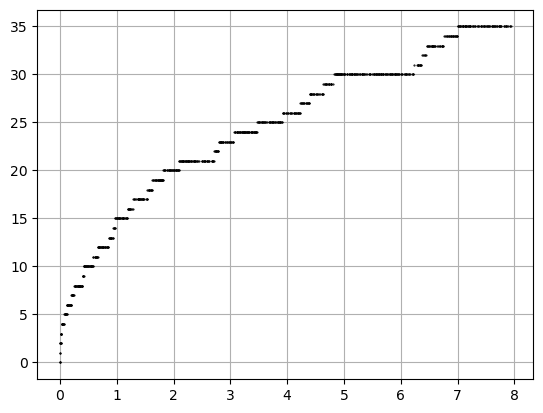

In [8]:
# Ячейка № 8

# вычисление и визуализация
# значений пи2-функции
Power, Value_of_Pi2 = Pi2_Function(N)

In [9]:
# Ячейка № 9

# задание функции, возвращающей
# изображение скатерти Улама,
# образуемой первыми простыми
# числами пар простых чисел-двойников
def Ulam_Polar_Twain(N):
    # вызов функции Twain_of_Prime
    Z = Twain_of_Prime(N)
    # задание массива, содержащего
    # номера пар простых чисел двойников
    m = np.linspace(1, Z.shape[0], Z.shape[0])

    # вычисление полярных координат
    # первых простых чисел
    # пар простых чисел-двойников
    x = Z[:, 5] * np.cos(m)
    y = Z[:, 5] * np.sin(m)

    # визуализация скатерти Улама
    F = plt.figure(figsize=(8, 8))
    F.add_subplot()
    plt.plot(x / N, y / N, ".k", markersize=1)
    plt.grid(True)
    return F

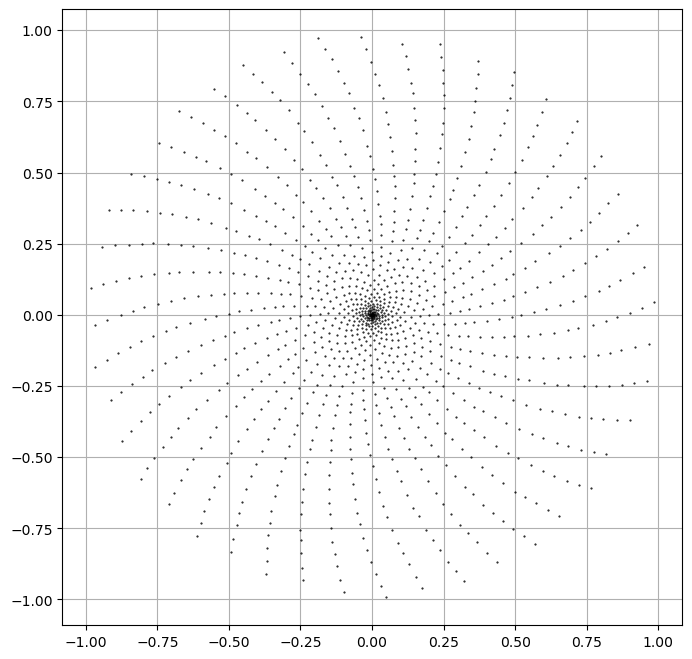

In [10]:
# Ячейка № 10

# визуализация скатерти Улама
F = Ulam_Polar_Twain(1 * 10**5)

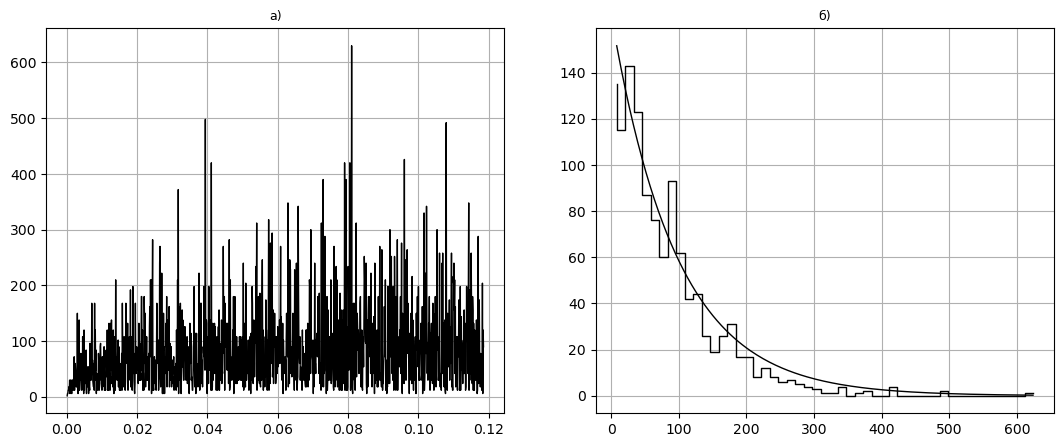

 a =  165.29379294814208  b =  0.01037238775159486


In [ ]:
# Ячейка № 11

# анализ статистических свойств
# первых разностей twin-чисел

# нахождение пар
# простых чисел-близнецов,
# находящихся в диапазоне [2, 10^5]
N = 10**5
Twain = Twain_of_Prime(N)

# вычисление значений
# первых разностей twin-чисел
d_Z = np.diff(Twain[:, 5])

# вычисление значения
# p порядка числа 10
# такого, что 10^p >= max(d_Z)
Power = Oder_of_Digit(len(d_Z))

F = plt.figure(figsize=(13, 11))
ax = F.add_subplot(2, 2, 1)
m = np.linspace(1, len(d_Z), len(d_Z))
plt.plot(m[:] / 10**Power, d_Z[:], "-k", lw=1)
ax.set_title("a)", fontsize=9)
plt.grid(True)


# вычисление эмпирической
# плотности распределения
# первых разностей twin-чисел
H = np.histogram(d_Z, bins=50)

# вычисление координат
# центров интервалов гистограммы
x = np.zeros(len(H[1]) - 1)
for i in range(len(H[1]) - 1):
    x[i] = (H[1][i] + H[1][i + 1]) / 2

# вычисление коэффициентов a, b, c
# аппроксимации эмпирической
# плотности распределения
# первых разностей twin-чисел
Coeff = curve_fit(lambda t, a, b: a * np.exp(-b * t), x, H[0], p0=[len(d_Z), 10**-2])
Сoeff2 = Coeff[0]


# задание функции, возвращающей
# значения аппроксимирующей функции
def func(x, a, b):
    return a * np.exp(-b * x)


# вычисление значений аппроксимирующей функции
x2 = np.linspace(x[0], x[len(x) - 1], 200)
y = func(x2, Сoeff2[0], Сoeff2[1])

# визуализация эмпирической плотности распределения
# и ее аппроксимации
ax = F.add_subplot(2, 2, 2)
plt.step(x, H[0], color="black", lw=1)
plt.plot(x2, y, "-k", lw=1)
plt.grid(True)
ax.set_title("б)", fontsize=9)
plt.show()
print(" a = ", Сoeff2[0], " b = ", Сoeff2[1])

In [ ]:
# Ячейка № 12

# задание функции, возвращающей
# значения первого из пары twain-чисел,
# принадлежащего m-ой P-кривой
def One_Twain_Select(Z, m):
    # входные переменные:
    # Z - массив, возвращенный
    #     функцией Twain_of_Prime
    # m - номер P-кривой
    Z_Select = np.array([], dtype=int)
    k = 0
    i = 1
    k = m - 1
    while k <= len(Z) - 1:
        Z_Select = np.hstack((Z_Select, Z[k, 5]))
        k = m - 1 + 44 * i
        i = i + 1

    return Z_Select

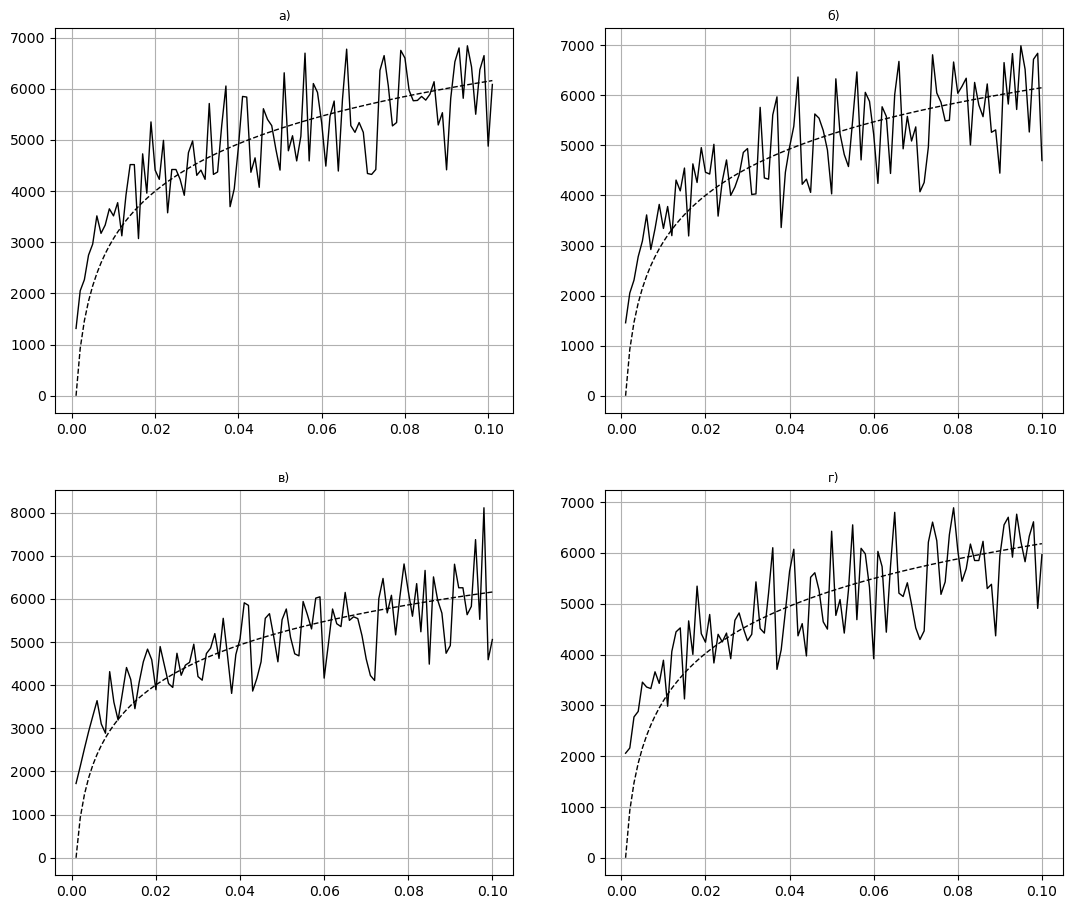

In [13]:
# Ячейка № 13

# анализ свойств зависимостей
# первых разностей простых чисел
# от порядкового номера
# первого числа twin-пары

# нахождение пар
# простых чисел-близнецов,
# находящихся в диапазоне [2, 10^5]
N = 5 * 10**5
Twain = Twain_of_Prime(N)

# выбор первых простых чисел
# из пар twin-чисел,
# находящихся на P-кривой № 1
P_Number = 1
Z1 = One_Twain_Select(Twain, P_Number)

# вычисление первых разностей
# первых простых чисел twin-пар,
# находящихся на Р-кривой № 1
d_Z1 = np.diff(Z1)

# задание массива, содержащего
# порядковые номера первого
# из пары twin-чисел чисел, находящегося
# на P-спирали № 1
m = np.linspace(1, len(d_Z1), len(d_Z1))

# вычисление коэффициентов a, b
# аппроксимации эмпирической
# плотности распределения
# первых разностей первых чисел
# twin-пары, находящихся на P-кривой № 1
param, param_cov = curve_fit(lambda t, a: a * np.log(t), m, d_Z1)
Coeff2 = Coeff[0]


# задание функции, возвращающей
# значения аппроксимирующей функции
def func(x, a):
    return a * np.log(x)


# вычисление значений аппроксимирующей функции
y = func(m, param)

# вычисление значения
# p порядка числа 10
# такого, что 10^p >= max(d_Z1)
Power = Oder_of_Digit(len(d_Z1))

# визуализация зависимости
# первых разностей первых twin-чисел,
# находящихся на Р-спирали № 1
#  от их порядкового номера и
# ее аппроксимации
F = plt.figure(figsize=(13, 11))
ax = F.add_subplot(2, 2, 1)
plt.plot(m[:] / 10**Power, d_Z1[:], "-k", lw=1)
plt.plot(m[:] / 10**Power, y, "--k", lw=1)
ax.set_title("a)", fontsize=9)
plt.grid(True)

# выбор первых простых чисел
# из пар twin-чисел,
# находящихся на P-кривой № 5
P_Number = 5
Z1 = One_Twain_Select(Twain, P_Number)

# вычисление первых разностей
# первых простых чисел twin-пар,
# находящихся на Р-кривой № 5
d_Z1 = np.diff(Z1)

# задание массива, содержащего
# порядковые номера первого
# из пары twin-чисел чисел, находящегося
# на P-спирали № 5
m = np.linspace(1, len(d_Z1), len(d_Z1))

# вычисление коэффициентов a, b
# аппроксимации зависимости
# первых разностей первых чисел
# twin-пары, находящихся на P-кривой № 5,
# от их порядкового номера
param, param_cov = curve_fit(lambda t, a: a * np.log(t), m, d_Z1)
Coeff2 = Coeff[0]

# вычисление значений аппроксимирующей функции
y = func(m, param)

# визуализация зависимости
# первых разностей первых twin-чисел,
# находящихся на Р-спирали № 5
#  от их порядкового номера и
# ее аппроксимации
ax = F.add_subplot(2, 2, 2)
m = np.linspace(1, len(d_Z1), len(d_Z1))
plt.plot(m[:] / 10**Power, d_Z1[:], "-k", lw=1)
plt.plot(m[:] / 10**Power, y, "--k", lw=1)
ax.set_title("б)", fontsize=9)
plt.grid(True)

# выбор первых простых чисел
# из пар twin-чисел,
# находящихся на P-кривой № 22
P_Number = 22
Z1 = One_Twain_Select(Twain, P_Number)
d_Z1 = np.diff(Z1)

# задание массива, содержащего
# порядковые номера первого
# из пары twin-чисел чисел, находящегося
# на P-спирали № 22
m = np.linspace(1, len(d_Z1), len(d_Z1))
param, param_cov = curve_fit(lambda t, a: a * np.log(t), m, d_Z1)
Coeff2 = Coeff[0]
# вычисление значений аппроксимирующей функции
y = func(m, param)

# выбор первых простых чисел
# из пар twin-чисел,
# находящихся на P-кривой № 22
Z1 = One_Twain_Select(Twain, P_Number)


# вычисление первых разностей
# первых простых чисел twin-пар,
# находящихся на Р-кривой № 22
d_Z1 = np.diff(Z1)

# визуализация зависимости
# первых разностей первых twin-чисел,
# находящихся на Р-спирали № 22
#  от их порядкового номера и
# ее аппроксимации
ax = F.add_subplot(2, 2, 3)
m = np.linspace(1, len(d_Z1), len(d_Z1))
plt.plot(m[:] / 10**Power, d_Z1[:], "-k", lw=1)
plt.plot(m[:] / 10**Power, y, "--k", lw=1)
ax.set_title("в)", fontsize=9)
plt.grid(True)

# выбор первых простых чисел
# из пар twin-чисел,
# находящихся на P-кривой № 44
P_Number = 44
Z1 = One_Twain_Select(Twain, P_Number)

# вычисление первых разностей
# первых простых чисел twin-пар,
# находящихся на Р-кривой № 44
d_Z1 = np.diff(Z1)

# задание массива, содержащего
# порядковые номера первого
# из пары twin-чисел чисел, находящегося
# на P-спирали № 44
m = np.linspace(1, len(d_Z1), len(d_Z1))

# вычисление коэффициентов a, b
# аппроксимации эмпирической
# плотности распределения
# первых разностей первых чисел
# twin-пары, находящихся на P-кривой № 44
param, param_cov = curve_fit(lambda t, a: a * np.log(t), m, d_Z1)
Coeff2 = Coeff[0]
# вычисление значений аппроксимирующей функции
y = func(m, param)

# визуализация зависимости
# первых разностей первых twin-чисел,
# находящихся на Р-спирали № 44
# от их порядкового номера и
# ее аппроксимации
ax = F.add_subplot(2, 2, 4)
m = np.linspace(1, len(d_Z1), len(d_Z1))
plt.plot(m[:] / 10**Power, d_Z1[:], "-k", lw=1)
plt.plot(m[:] / 10**Power, y, "--k", lw=1)
ax.set_title("г)", fontsize=9)
plt.grid(True)

plt.show()